# Notebook 03 - Análise Exploratória (EDA)

**Objetivo:** descrever visualmente a relação entre `ConvertedCompYearly` (salário em USD) e os blocos de variáveis explicativas, sempre limitando categorias ao **top 5**, em coerência com a estratégia "dividir e conquistar" do projeto.

**Entrada:** `data/processed/df_limpo.csv` (14.171 desenvolvedores, 18 colunas)

**Saídas:** figuras em `output/figures/` para uso na apresentação.

**Cobertura dos requisitos do PDF:**
- Identificação das variáveis (seção 1)
- Diagrama de dispersão (seção 3)
- Coeficiente de correlação (seções 3 e 7)
- Distribuições e comparações por bloco (seções 2, 4, 5, 6)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

PASTA_DADOS = Path('../data/processed')
PASTA_FIGURAS = Path('../output/figures')
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PASTA_DADOS / 'df_limpo.csv')
print(f'Linhas: {len(df):,}')
print(f'Colunas: {df.shape[1]}')
df.head(3)

Linhas: 14,171
Colunas: 18


,ResponseId,MainBranch,EdLevel,Employment,YearsCode,DevType,Country,LanguageHaveWorkedWith,ConvertedCompYearly,Country_agrupado,DevType_agrupado,EdLevel_agrupado,lang_JavaScript,lang_HTML_CSS,lang_SQL,lang_Python,lang_TypeScript,nivel_experiencia
0,1,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",Ukraine,Bash/Shell (all shells);Dart;SQL,61256.0,Outros,mobile,Mestrado,0,0,1,0,0,Senior
1,2,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end",Netherlands,Java,104413.0,Outros,backend,Outros,0,0,0,0,0,Senior
2,3,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",12.0,"Developer, front-end",Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,53061.0,Outros,frontend,Bacharelado,1,1,0,0,1,Senior


## 1. Identificação das variáveis

| Variável | Tipo | Papel |
|---|---|---|
| `ConvertedCompYearly` | quantitativa contínua | **Y** (salário anual em USD) |
| `YearsCode` | quantitativa discreta | X (anos de experiência) |
| `Country_agrupado` | qualitativa nominal | X (top 5 países + Outros) |
| `DevType_agrupado` | qualitativa nominal | X (top 5 áreas) |
| `EdLevel_agrupado` | qualitativa ordinal | X (top 5 níveis + Outros) |
| `lang_*` | qualitativa binária | X (top 5 linguagens, dummies 0/1) |
| `nivel_experiencia` | qualitativa ordinal | X auxiliar (Junior/Pleno/Senior) |

## 2. Distribuição do salário (Y)

Histograma do salário anual em USD para mostrar a forma da distribuição (assimetria à direita, mesmo após o corte de outliers no notebook 02).

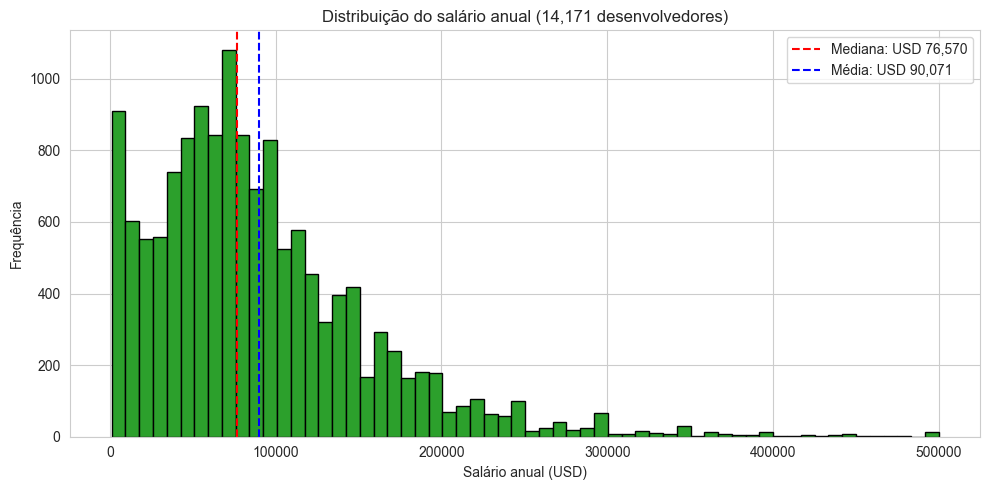


Resumo estatistico do salario (USD):
count     14,171
mean      90,071
std       67,564
min        1,000
25%       44,666
50%       76,570
75%      120,000
max      500,000
Name: ConvertedCompYearly, dtype: str


In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['ConvertedCompYearly'], bins=60, color='#2ca02c', edgecolor='black')
ax.axvline(df['ConvertedCompYearly'].median(), color='red', linestyle='--', label=f"Mediana: USD {df['ConvertedCompYearly'].median():,.0f}")
ax.axvline(df['ConvertedCompYearly'].mean(), color='blue', linestyle='--', label=f"Média: USD {df['ConvertedCompYearly'].mean():,.0f}")
ax.set_xlabel('Salário anual (USD)')
ax.set_ylabel('Frequência')
ax.set_title(f'Distribuição do salário anual ({len(df):,} desenvolvedores)')
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_distribuicao_salario.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nResumo estatistico do salario (USD):')
print(df['ConvertedCompYearly'].describe().apply(lambda x: f'{x:,.0f}'))

## 3. Diagrama de dispersão: Salário × Experiência

Atende o requisito do PDF de diagrama de dispersão e coeficiente de correlação. Usa a única variável quantitativa explicativa (`YearsCode`).

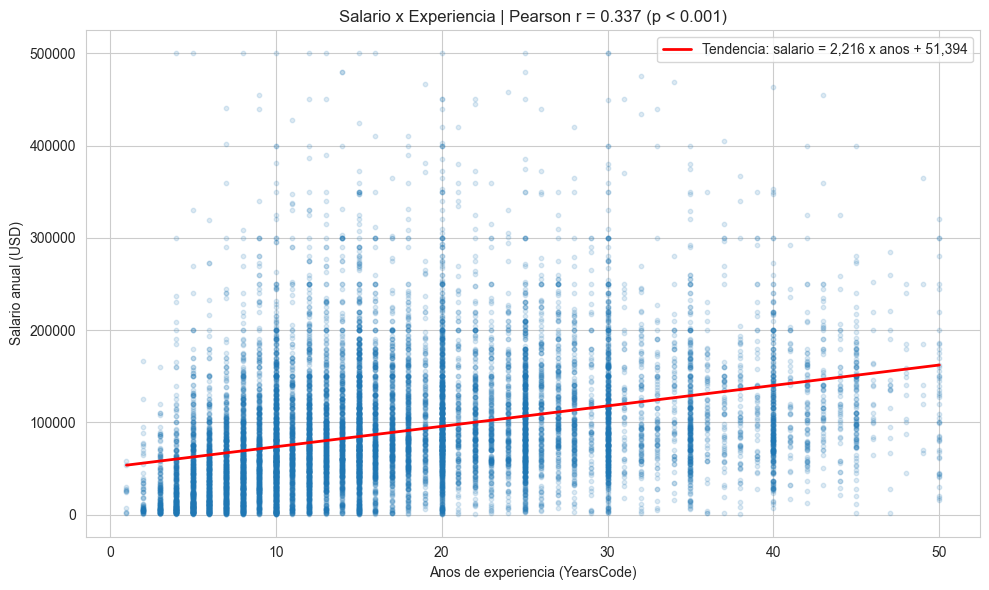


Correlacao de Pearson (Salario x YearsCode): r = 0.3366, p = 0.00e+00


In [3]:
from scipy.stats import pearsonr

r, p = pearsonr(df['YearsCode'], df['ConvertedCompYearly'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['YearsCode'], df['ConvertedCompYearly'], alpha=0.15, s=10, color='#1f77b4')

coef = np.polyfit(df['YearsCode'], df['ConvertedCompYearly'], 1)
x_lin = np.linspace(df['YearsCode'].min(), df['YearsCode'].max(), 100)
ax.plot(x_lin, np.polyval(coef, x_lin), color='red', linewidth=2, label=f'Tendencia: salario = {coef[0]:,.0f} x anos + {coef[1]:,.0f}')

ax.set_xlabel('Anos de experiencia (YearsCode)')
ax.set_ylabel('Salario anual (USD)')
ax.set_title(f'Salario x Experiencia | Pearson r = {r:.3f} (p < 0.001)')
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_dispersao_salario_experiencia.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nCorrelacao de Pearson (Salario x YearsCode): r = {r:.4f}, p = {p:.2e}')

## 4. Salário por País (top 5 + Outros)

Boxplot da distribuição salarial por país (ordenado pela mediana). A amplitude entre países é o primeiro indício visual da força do bloco País sobre o salário.

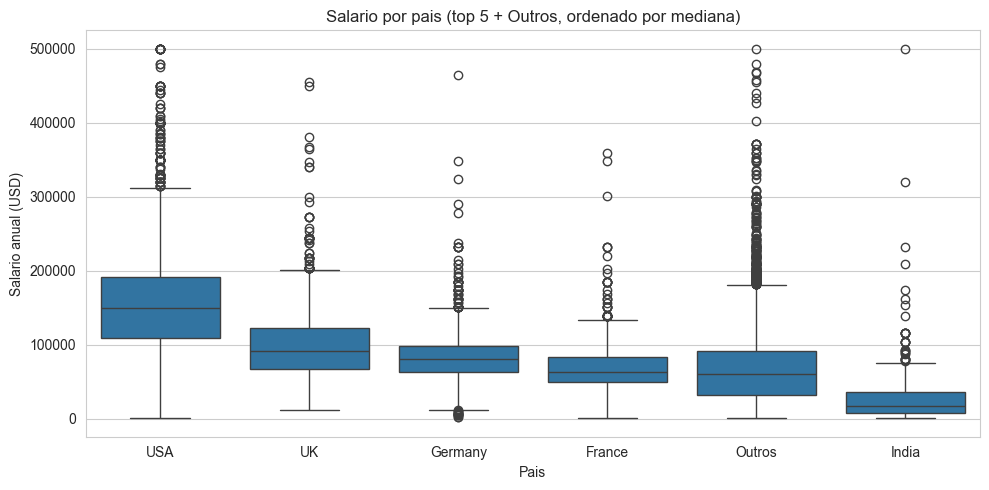


Mediana salarial por pais (USD):
Country_agrupado
USA        149,950
UK          91,215
Germany     81,210
France      63,228
Outros      60,328
India       17,436
Name: ConvertedCompYearly, dtype: str


In [4]:
ordem_pais = df.groupby('Country_agrupado')['ConvertedCompYearly'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Country_agrupado', y='ConvertedCompYearly', order=ordem_pais, ax=ax, color='#1f77b4')
ax.set_xlabel('Pais')
ax.set_ylabel('Salario anual (USD)')
ax.set_title('Salario por pais (top 5 + Outros, ordenado por mediana)')
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_boxplot_salario_pais.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nMediana salarial por pais (USD):')
print(df.groupby('Country_agrupado')['ConvertedCompYearly'].median().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}'))

## 5. Salário por Área de Atuação (DevType)

Boxplot por macro-categoria de atuação (5 níveis).

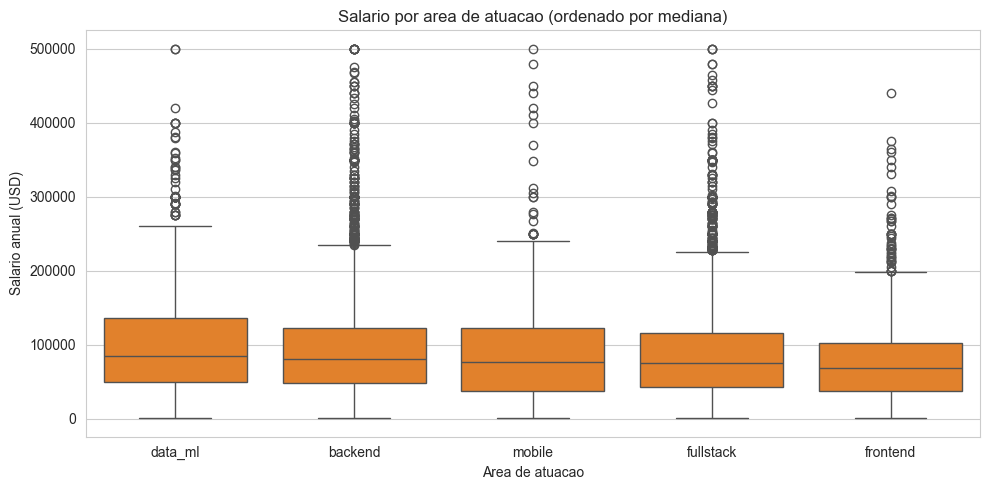


Mediana salarial por area (USD):
DevType_agrupado
data_ml      84,691
backend      81,210
mobile       76,326
fullstack    75,000
frontend     68,071
Name: ConvertedCompYearly, dtype: str


In [5]:
ordem_devtype = df.groupby('DevType_agrupado')['ConvertedCompYearly'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='DevType_agrupado', y='ConvertedCompYearly', order=ordem_devtype, ax=ax, color='#ff7f0e')
ax.set_xlabel('Area de atuacao')
ax.set_ylabel('Salario anual (USD)')
ax.set_title('Salario por area de atuacao (ordenado por mediana)')
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_boxplot_salario_devtype.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nMediana salarial por area (USD):')
print(df.groupby('DevType_agrupado')['ConvertedCompYearly'].median().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}'))

## 6. Salário por Escolaridade e por Linguagem

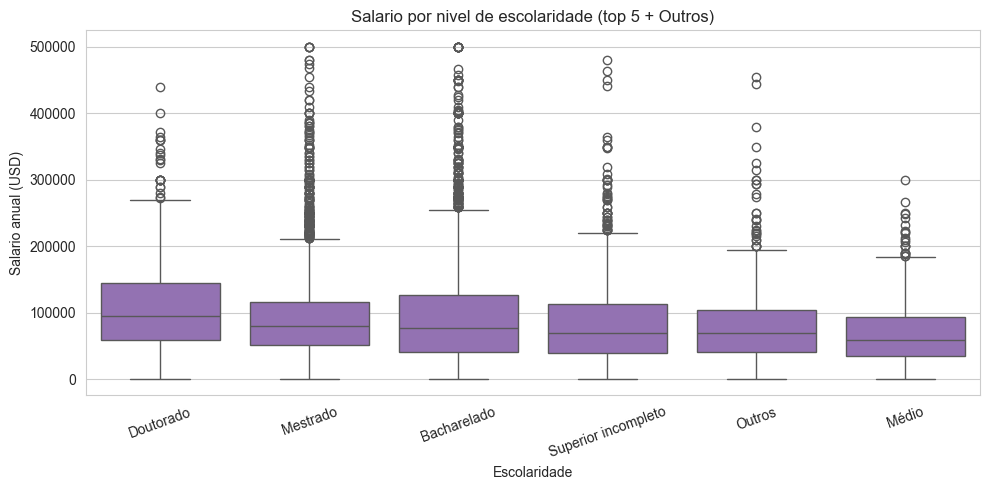


Mediana salarial por escolaridade (USD):
EdLevel_agrupado
Doutorado              94,846
Mestrado               80,000
Bacharelado            78,000
Superior incompleto    70,000
Outros                 69,609
Médio                  60,000
Name: ConvertedCompYearly, dtype: str


In [6]:
ordem_edu = df.groupby('EdLevel_agrupado')['ConvertedCompYearly'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='EdLevel_agrupado', y='ConvertedCompYearly', order=ordem_edu, ax=ax, color='#9467bd')
ax.set_xlabel('Escolaridade')
ax.set_ylabel('Salario anual (USD)')
ax.set_title('Salario por nivel de escolaridade (top 5 + Outros)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_boxplot_salario_edlevel.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nMediana salarial por escolaridade (USD):')
print(df.groupby('EdLevel_agrupado')['ConvertedCompYearly'].median().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}'))

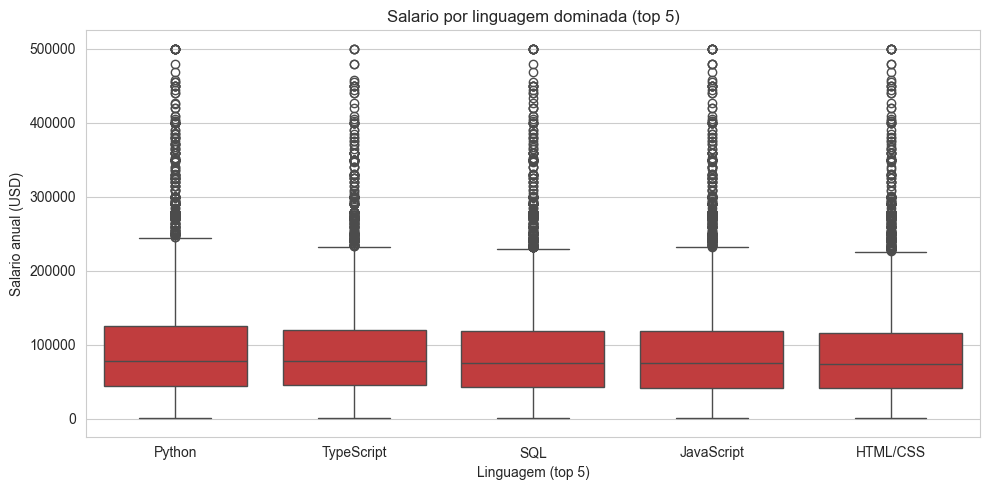


Mediana salarial por linguagem dominada (USD):
 Linguagem  Mediana_USD    N
    Python      78962.0 7381
TypeScript      77730.0 7246
       SQL      75410.0 8939
JavaScript      75000.0 9912
  HTML/CSS      74843.0 9139


In [7]:
cols_lang = [c for c in df.columns if c.startswith('lang_')]

linhas = []
for c in cols_lang:
    grupo = df[df[c] == 1]['ConvertedCompYearly']
    nome = c.replace('lang_', '').replace('_', '/')
    linhas.append({'Linguagem': nome, 'Mediana_USD': grupo.median(), 'N': len(grupo)})
tabela_lang = pd.DataFrame(linhas).sort_values('Mediana_USD', ascending=False)

long = []
for c in cols_lang:
    nome = c.replace('lang_', '').replace('_', '/')
    long.append(df[df[c] == 1].assign(Linguagem=nome)[['Linguagem', 'ConvertedCompYearly']])
df_long = pd.concat(long, ignore_index=True)
ordem_lang = tabela_lang['Linguagem'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_long, x='Linguagem', y='ConvertedCompYearly', order=ordem_lang, ax=ax, color='#d62728')
ax.set_xlabel('Linguagem (top 5)')
ax.set_ylabel('Salario anual (USD)')
ax.set_title('Salario por linguagem dominada (top 5)')
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_boxplot_salario_linguagem.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nMediana salarial por linguagem dominada (USD):')
print(tabela_lang.to_string(index=False))

## 7. Heatmap de correlação (variáveis numéricas)

Pearson entre as variáveis quantitativas e dummies de linguagem. Mostra que correlações univariadas tendem a ser fracas — daí a necessidade de comparar **R² por bloco** no notebook 04, em vez de olhar correlações isoladas.

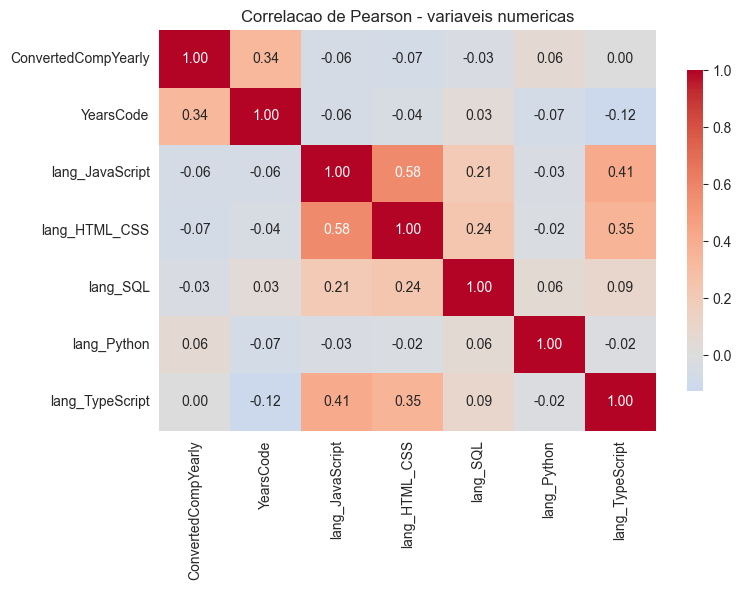

In [8]:
cols_num = ['ConvertedCompYearly', 'YearsCode'] + [c for c in df.columns if c.startswith('lang_')]
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlacao de Pearson - variaveis numericas')
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '03_heatmap_correlacao.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Síntese visual

**O que vemos antes do modelo:**
- O bloco **País** é o que mostra a maior amplitude de medianas (USA no topo, demais bem abaixo) — hipótese forte de ser o X dominante.
- **Área de atuação** (DevType) também separa bem os grupos, com Data/ML e Backend acima de Frontend.
- **Escolaridade** mostra um efeito mais discreto (mestrado/doutorado ligeiramente acima).
- **Linguagem isolada** tem efeito modesto: as top 5 são linguagens muito comuns, então as medianas ficam próximas.
- Correlação Pearson com `YearsCode` é moderada (em torno de 0,3) — experiência importa, mas não explica sozinha o salário.

Tudo isso é confirmado quantitativamente no **notebook 04 (importância por R² parcial)**, onde cada bloco compete pela explicação do salário.